In [60]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt # THIS ISN't FUNCTIONAL, IT's JUST TEMPORARY
import time
words = open('names.txt', 'r').read().splitlines()

In [61]:
class Value:
    def __init__(self, data, _children=(), _opp="", label=""):
        self.data = np.array(data)
        self.prev = set(_children)
        self.grad = np.zeros_like(self.data, dtype=float)
        self.opp = _opp
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    @property
    def shape(self):
        return self.data.shape

    @staticmethod
    def _unbroadcast(grad, shape):
        # sum over axes that were broadcast so grad matches `shape`
        while grad.ndim > len(shape):
            grad = grad.sum(axis=0)
        for i, dim in enumerate(shape):
            if dim == 1 and grad.shape[i] != 1:
                grad = grad.sum(axis=i, keepdims=True)
        return grad

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #Make it still work if other is an integer and not a Value (a+1, for instance)

        def _backward():
            self.grad += Value._unbroadcast(out.grad, self.data.shape)
            other.grad += Value._unbroadcast(out.grad, other.data.shape)

        out = Value(self.data+other.data, (self, other), "+")
        out._backward = _backward
        return out
    
    def __matmul__(self, other):
        out = Value(self.data @ other.data, (self, other), "@")
        def _backward():
            # works for 2D (n,k)@(k,m) and batched (...,n,k)@(k,m) inputs
            sg = out.grad @ np.swapaxes(other.data, -1, -2)
            og = np.swapaxes(self.data, -1, -2) @ out.grad
            self.grad += Value._unbroadcast(sg, self.data.shape)
            other.grad += Value._unbroadcast(og, other.data.shape)
        
        out._backward = _backward
        
        return out
    
    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __neg__(self):
        return self * -1
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        def _backward():
            self.grad += Value._unbroadcast(other.data * out.grad, self.data.shape)
            other.grad += Value._unbroadcast(self.data * out.grad, other.data.shape)

        out = Value(self.data * other.data, (self, other), "*")
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
        #Add support for integer * Value (since 2*a doesn't work, but a*2 does)
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "not an int or float"
        out = Value(self.data**other, (self, ), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # embedding-style lookup: idx is an int array of indices into axis 0
        out = Value(self.data[idx], (self, ), "getitem")

        def _backward():
            np.add.at(self.grad, idx, out.grad) # scatter-add grads back to the rows that were selected

        out._backward = _backward
        return out

    def reshape(self, *shape):
        out = Value(self.data.reshape(*shape), (self, ), "reshape")

        def _backward():
            self.grad += out.grad.reshape(self.data.shape)

        out._backward = _backward
        return out

    def squeeze(self, axis=None):
        out = Value(np.squeeze(self.data, axis=axis), (self, ), "squeeze")

        def _backward():
            self.grad += out.grad.reshape(self.data.shape)

        out._backward = _backward
        return out
    
    def tanh(self):
        x=self.data
        t = np.tanh(x)

        def _backward():
            self.grad += (1-t**2) * out.grad

        out = Value(t, (self, ), "tanh")
        out._backward=_backward
        return out
    
    def exp(self):
        x=self.data

        def _backward():
            self.grad += (np.exp(x)*out.data)

        out = Value(np.exp(x), (self, ), "exp")
        out._backward=_backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = np.ones_like(self.data)

        for node in reversed(topo):
            node._backward()

#Helper function
def oneHot(c):
    out = [0 for _ in range(27)]
    curIndex = ord(c)-97
    if curIndex <0:
        curIndex=26 # Change it if it's a period
    out[curIndex] = 1
    return out
def cross_entropy(logits, targets):
    e = np.exp(logits.data)
    probs = e / e.sum(axis=1, keepdims=True)
    
    correct_probs = probs[np.arange(len(targets)), targets]
    loss = -np.log(correct_probs).mean()
    
    out = Value(loss, (logits,), "cross_entropy")
    
    def _backward():
        # gradient of cross entropy + softmax combined is just (probs - 1_correct) / batch_size
        dlogits = probs.copy()
        dlogits[np.arange(len(targets)), targets] -= 1
        dlogits /= len(targets)
        logits.grad += dlogits
    
    out._backward = _backward
    return out
def prog(val, total):
    length = 20
    out = "["
    for i in range(length):
        if i < math.ceil((val/total) * length):
            out += "#"
        else:
            out += "-"
    return out + "]"
def trunc(number, digits):
    stepper = 10 ** digits
    return math.trunc(number * stepper) / stepper

In [62]:
# defining weights
W1 = Value(np.random.randn(30, 200) * (5/3) / (30**0.5))  # embedding_size * block_size -> hidden
#b1 = Value(np.zeros(200))
W2 = Value(np.random.randn(200, 27) * 0.01)  # hidden -> logits 
b2 = Value(np.zeros(27))
charEncodings = Value(np.random.randn(27,10)) #Increase to 10 dimensional embeddings
bngain = Value(np.ones((1, 200)))
bnbias = Value(np.zeros((1, 200)))

parameters = [charEncodings, W1, W2, b2, bngain, bnbias] # for easy access during 
finished = 0
lossGraph=[]
bnmean_running = Value(np.zeros((1, 200)))
bnstd_running = Value(np.ones((1, 200)))

In [ ]:
stoi = {s:i for i,s in enumerate(sorted(list(set(''.join(words)))))}
stoi['.']=26
itos = {i:s for s,i in stoi.items()}

blockSize = 8 # Increase the amount of context
inputs, outputs = [],[]

In [64]:
for w in words:
    context = [0] * blockSize # start with 3 starting characters
    for ch in w + '.':
        ix = stoi[ch] # get the current character
        inputs.append(context) # add input to inputs, output to outputs
        outputs.append(ix)
        context = context[1:] + [ix] # update the context

In [65]:
n1 = int(.8 * len(inputs))
n2 = int(.9 * len(inputs))

trainIn = inputs[:n1] # Training data (80%)
trainOut = outputs[:n1]
devIn = inputs[n1:n2] # Development data (10%) For use on like testing random ideas, etc
devOut = outputs[n1:n2]
testIn = inputs[n2:] #  Test data (10%) 
testOut = outputs[n2:]

In [ ]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = Value(np.random.randn(fan_in, fan_out) / fan_in**0.5)
        self.bias = Value(np.zeros(fan_out)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])



class BatchNorm1D:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained via backprop)
        self.gamma = Value(np.ones(dim))
        self.beta = Value(np.zeros(dim))
        # buffers (updated with a running average, not backprop)
        self.running_mean = np.zeros(dim)
        self.running_var = np.ones(dim)

    def __call__(self, x):
        # reduce over the batch dim for 2D (B, C) input and over (batch, time) for 3D (B, T, C)
        dim = 0 if x.data.ndim == 2 else (0, 1)
        # calculate the forward pass
        if self.training:
            xmean = np.mean(x.data, axis=dim, keepdims=True) # batch mean
            xvar = np.var(x.data, axis=dim, keepdims=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / (xvar + self.eps) ** .5 # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = x.tanh()
        return self.out
    def parameters(self):
        return []
    
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    rng = np.random
    self.weight = Value(rng.standard_normal((num_embeddings, embedding_dim)))
    
  def __call__(self, IX):
    self.out = self.weight[IX] # Value.__getitem__ keeps this in the autograd graph
    return self.out
  
  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:
  
  def __init__(self, n):
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
    x = x.reshape(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  # So what it does, is it takes the input, which is a tensor of shape (Batch size, block size, embedding dimensions)
  # The old Flatten() combined block size and embedding dimesnions, so the new tensor is (Batch size, block size * embedding dimensions)
  # The new one doesn't, it slowly merges each block size. So for n=2, it will make blocksize/2 lists of embedding dimensions*2 values.
  # Then on the next call, the same thing, so now it's (blocksize/2)/2 lists of (dimensions*2)*2,
  # and then again on ((blocksize/2)/2)/2 lists of ((dimensions*2)*2)*2, which results in the same end size as the old Flatten(), it just does it gradually.

  
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
vocab_size = 27

# each FlattenConsecutive(2) concatenates 2 neighbours, so the next Linear sees 2x the features
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# last layer: make less confident
model.layers[-1].weight.data *= 0.1
# all other layers: apply gain
for layer in model.layers[:-1]:
    if isinstance(layer, Linear):
        layer.weight.data *= 1.0 #5/3

parameters = model.parameters()
print(sum(p.data.size for p in parameters)) # number of parameters in total

45597


In [139]:
max_steps = 2000000
batch_size = 32
lossi = []
ud = []

for layer in model.layers:
    if isinstance(layer, BatchNorm1D):
        layer.training = True # train mode: use batch stats and update the running buffers

trainInArr = np.array(trainIn)   # (N, blockSize) context indices
trainOutArr = np.array(trainOut) # (N,) target indices

for i in range(max_steps):

    # minibatch construct
    ix = np.random.randint(0, trainInArr.shape[0], (batch_size,))
    Xb, Yb = trainInArr[ix], trainOutArr[ix]

    # forward pass
    logits = model(Xb)
    loss = cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = np.zeros_like(p.data, dtype=float)
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {float(loss.data):.4f}')
    lossi.append(np.log10(float(loss.data)))
    ud.append([np.log10(np.std(lr * p.grad) / np.std(p.data)) for p in parameters])

    if i >= 1000:
        # break # If you want to.
        pass

      0/2000000: 1.7961
  10000/2000000: 2.0712
  20000/2000000: 2.0184
  30000/2000000: 2.4102
  40000/2000000: 1.8515
  50000/2000000: 1.9705
  60000/2000000: 1.9336
  70000/2000000: 2.0652
  80000/2000000: 2.0782
  90000/2000000: 2.2402
 100000/2000000: 2.0794
 110000/2000000: 1.8034
 120000/2000000: 1.5685
 130000/2000000: 1.9307
 140000/2000000: 2.0751
 150000/2000000: 1.8618
 160000/2000000: 2.1657
 170000/2000000: 1.8427
 180000/2000000: 1.8924
 190000/2000000: 1.6751
 200000/2000000: 2.0573
 210000/2000000: 1.4057
 220000/2000000: 1.8866
 230000/2000000: 2.0326
 240000/2000000: 2.0153
 250000/2000000: 1.5739
 260000/2000000: 1.7647
 270000/2000000: 1.9603
 280000/2000000: 1.5846
 290000/2000000: 1.7421
 300000/2000000: 2.1432
 310000/2000000: 1.6937
 320000/2000000: 2.1785
 330000/2000000: 1.5312
 340000/2000000: 2.0605
 350000/2000000: 2.3279
 360000/2000000: 2.1736
 370000/2000000: 2.1071
 380000/2000000: 1.7506
 390000/2000000: 1.7789
 400000/2000000: 2.0737
 410000/2000000:

layer 4 (      Tanh): mean -0.13, std 0.92, saturated: 69.71%
layer 8 (      Tanh): mean -0.00, std 0.89, saturated: 55.41%
layer 12 (      Tanh): mean -0.03, std 0.75, saturated: 16.84%


Text(0.5, 1.0, 'activation distribution')

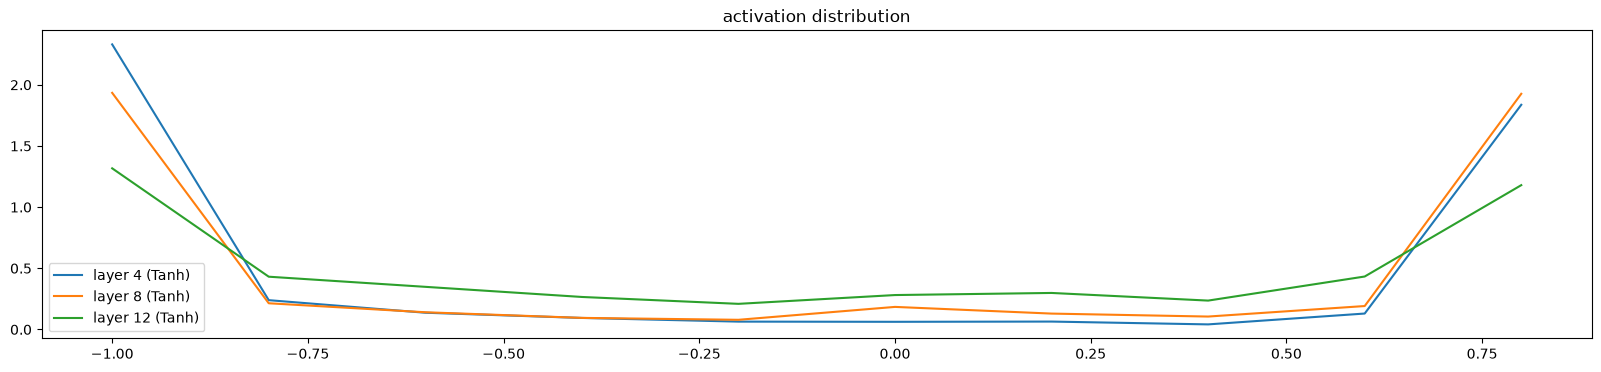

In [116]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(model.layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.data
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (
            i, layer.__class__.__name__, t.mean(), t.std(), (np.abs(t) > 0.97).mean() * 100))
        hy, hx = np.histogram(t, density=True)
        plt.plot(hx[:-1], hy)
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')


C:\Users\28taidan\AppData\Local\Temp\ipykernel_4384\2320815609.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  betterLoss.append(cur/(len(lossi)%SMUSH))


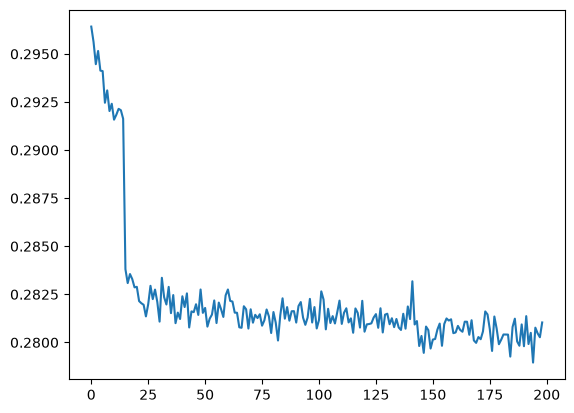

In [141]:
# THis is bad bc 32 is a bad loss size
# plt.plot(lossi)

# So we split lossi into 1000 long segments, average them, and plot it all.
# We can't make it a tensor like he does, so

SMUSH = 10000 # resolution of graph. <50 really has too much noise, 1000 is reccomended. Needed bc 32 as a batch size has too much variation.
betterLoss = []
cur = 0
for i in range(len(lossi)):
    cur += lossi[i]
    if i % SMUSH == 0 and i>0:
        betterLoss.append(cur/SMUSH)
        cur = 0
betterLoss.append(cur/(len(lossi)%SMUSH))

plt.plot(betterLoss)


In [138]:
# put batchnorm layers into eval mode so they use the running stats instead of
# per-batch stats (a batch of size 1 has zero variance, which would blow up otherwise)
for layer in model.layers:
    if isinstance(layer, BatchNorm1D):
        layer.training = False

# sample from the model
rng = np.random

for _ in range(20):

    out = []
    context = [26] * blockSize # initialize with the '.' padding token
    while True:
        # forward pass the neural net: feed the (1, blockSize) context of indices
        x = np.array([context]) # (1, blockSize); the Embedding layer looks these up
        logits = model(x)
        e = np.exp(logits.data)
        probs = e / e.sum(axis=1, keepdims=True)
        # sample from the distribution
        ix = rng.choice(vocab_size, p=probs[0])
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 26:
            break

    print(''.join(itos[i] for i in out[:-1])) # decode and print the generated word, dropping the trailing '.'

ye

ye

y

l
l
e
iy
my
l


d
iya


l
n


In [71]:
import json
import os

def export_weights(path='docs/weights.json'):
    # make sure batchnorm layers use running stats, matching the sampling cell above
    for layer in layers:
        if isinstance(layer, BatchNorm1D):
            layer.training = False

    model = {
        "blockSize": blockSize,
        "vocabSize": vocab_size,
        "nEmbd": n_embd,
        "itos": {str(k): v for k, v in itos.items()},
        "C": C.data.tolist(),
        "layers": [],
    }
    for layer in layers:
        if isinstance(layer, Linear):
            model["layers"].append({
                "type": "linear",
                "weight": layer.weight.data.tolist(),
                "bias": layer.bias.data.tolist() if layer.bias is not None else None,
            })
        elif isinstance(layer, BatchNorm1D):
            # running_mean/var start as (dim,) but broadcast to (1, dim) after the
            # first training step, so flatten everything to guarantee 1-D arrays for
            # the web app. (A nested [[...]] makes the JS index into undefined -> NaN,
            # so the model only ever emits the stop token and every name comes out empty.)
            model["layers"].append({
                "type": "batchnorm",
                "gamma": np.asarray(layer.gamma.data).reshape(-1).tolist(),
                "beta": np.asarray(layer.beta.data).reshape(-1).tolist(),
                "runningMean": np.asarray(layer.running_mean).reshape(-1).tolist(),
                "runningVar": np.asarray(layer.running_var).reshape(-1).tolist(),
                "eps": layer.eps,
            })
        elif isinstance(layer, Tanh):
            model["layers"].append({"type": "tanh"})

    dirname = os.path.dirname(path)
    if dirname:
        os.makedirs(dirname, exist_ok=True)
    with open(path, 'w') as f:
        json.dump(model, f)
    print(f"Wrote {path} ({os.path.getsize(path)/1024:.1f} KB)")

export_weights()


Wrote docs/weights.json (981.5 KB)


In [72]:
# dlogprobs = np.zeros_like(logprobs)
# dlogprobs[range(n), Yb] = -1.0/n
# dprobs = (1.0 / probs) * dlogprobs
# dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
# dcounts = counts_sum_inv * dprobs
# dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
# dcounts += np.ones_like(counts) * dcounts_sum_inv
# dnorm_logits = counts + dcounts
# dlogits = dnorm_logits.clone()
# dlogitmaxes  (-dnorm_logits).sum(1, keepdim=True)
# dlogits = F.onehot(logits.max(1).indices, numclasses=logits.shape[1]) ( dlogitmaxes)

# This bit should be ignored
# It's from lecture 4 on Backpropogation, where he implemented backpropogation manually, instead of pyTorch's loss.backward()
# However, I already implemented it, since I'm not using Pytorch and had to write the .backward function myself.
# So I just (tried to) follow along with the excercizes in the lecture and ensured that my code was free from errors.